<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/better-visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Better Visualisations
...todo...


...TODO: need to think about copying in the most basic examples of LR experiments to show the benefit for the Loss curves.

In [ ]:
# Install Training Instrumentation Toolkit
# (locked to specific git revision so this notebook always works)
import os
import sys
if not os.path.isdir('training-instrumentation-toolkit'):
  !git clone https://github.com/malcolmlett/training-instrumentation-toolkit.git
  !cd training-instrumentation-toolkit && git checkout 36a24d0
sys.path.append('training-instrumentation-toolkit')

# Imports
import sys
import train_instrumentation as tinstr
import train_explainer as texpl
import tensorflow as tf
from tensorflow.keras import layers
import tqdm
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import matplotlib.ticker as mticker
import sklearn
import scipy

# Prefer consistent behaviour
tf.config.experimental.enable_op_determinism()

Cloning into 'training-instrumentation-toolkit'...
remote: Enumerating objects: 1458, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 1458 (delta 13), reused 9 (delta 7), pack-reused 1440 (from 2)
Receiving objects: 100% (1458/1458), 145.44 MiB | 28.52 MiB/s, done.
Resolving deltas: 100% (870/870), done.
Note: switching to '36a24d0'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 36a24d0 Merge remote-tracking branch 'refs/remotes/origin/main'


In [ ]:
# Versions and hardware used when this notebook was last succesfully run
print(f"Python:     {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras:      {tf.keras.__version__}")
print(f"Numpy:      {np.__version__}")
print(f"Devices:    {tf.config.list_physical_devices()}")

Python:     3.11.12 (main, Apr  9 2025, 08:55:54) [GCC 11.4.0]
TensorFlow: 2.18.0
Keras:      3.8.0
Numpy:      2.0.2
Devices:    [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Setup

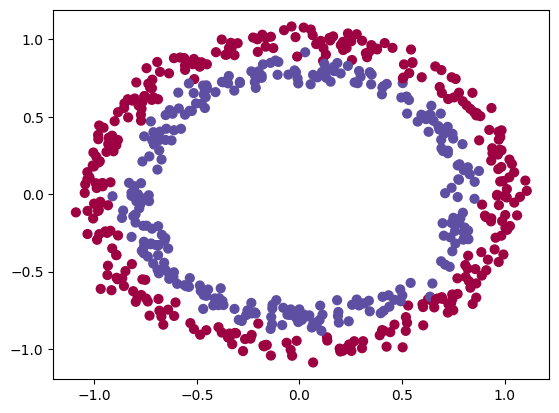

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_186 (Dense)               │ (None, 100)            │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_187 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_188 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_189 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_190 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_191 (Dense)               │ (None, 5)              │           505 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_192 (Dense)               │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,611 (162.54 KB)

 Trainable params: 41,411 (161.76 KB)

 Non-trainable params: 200 (800.00 B)

In [ ]:
# Using a slightly more elaborate model than needed for such a simple task in order
# to illustrate how dropout and normalization layers appear in visualisations
def binary_classification_model():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(rate=0.2),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(5, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(1, activation='sigmoid', kernel_initializer='he_normal')
  ])
  return model

def binary_classification_dataset():
  X, Y = sklearn.datasets.make_circles(n_samples=3000, noise=.05)
  return X, Y

train_X, train_Y = binary_classification_dataset()
plt.scatter(train_X[0:600, 0], train_X[0:600, 1], c=train_Y[0:600], s=40, cmap=plt.cm.Spectral);
plt.show()

binary_classification_model().summary()

# Custom Training Loop
This illustrates the simplest form of a custom training loop that collects the following while also providing some of the basic support that you get out of the box from the standard model.fit():
* Loss and metrics per-step instead of per-epoch
* Variables at each step (ie: weights, biases, etc.)
* Gradients at each step (of weights, biases, etc.)
* Layer outputs
* Gradients of layer outputs

  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_700']
Received: inputs=Tensor(shape=(32, 2))
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_700']
Received: inputs=Tensor(shape=(24, 2))
  warnings.warn(msg)
100%|██████████| 5/5 [01:05<00:00, 13.18s/it]


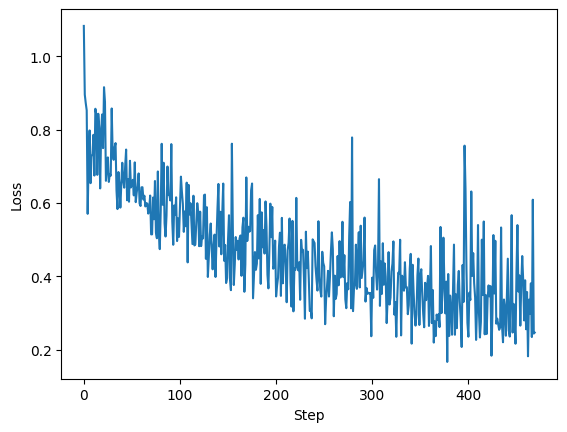

In [ ]:
def custom_fit(model, train_dataset, epochs, optimizer):
  # unpack model during training so we get access to individual layer outputs
  monitoring_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[model.outputs] + [layer.output for layer in model.layers])

  loss_history = []
  metrics_history = []
  variables_history = []
  gradients_history = []
  layer_outputs_history = []
  layer_gradients_history = []

  for epoch in tqdm.tqdm(range(epochs)):
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
      with tf.GradientTape() as tape:
        monitoring_outputs = monitoring_model(x_batch_train, training=True)
        y_pred = monitoring_outputs[0][0]
        layer_outputs = monitoring_outputs[1:]
        loss = model.compute_loss(x_batch_train, y_batch_train, y_pred, training=True)
        loss = optimizer.scale_loss(loss)
      all_grads = tape.gradient(loss, model.trainable_weights + layer_outputs)
      trainable_grads = all_grads[:len(model.trainable_variables)]
      output_grads = all_grads[len(model.trainable_variables):]
      optimizer.apply_gradients(zip(trainable_grads, model.trainable_weights))
      metrics = model.compute_metrics(x_batch_train, y_batch_train, y_pred)

      loss_history.append(loss)
      metrics_history.append(metrics)
      variables_history.append([tf.identity(v) for v in model.trainable_variables])
      gradients_history.append(trainable_grads)
      layer_outputs_history.append(layer_outputs)
      layer_gradients_history.append(output_grads)

  return loss_history, metrics_history, variables_history, gradients_history, layer_outputs_history, layer_gradients_history

# try it out
tf.keras.utils.set_random_seed(1)
model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'mse'])
train_X, train_Y = binary_classification_dataset()
train_dataset = tf.data.Dataset.from_tensor_slices((train_X, train_Y)).batch(32)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
hists = custom_fit(model, train_dataset, 5, optimizer)

# plot loss curve
plt.plot(hists[0])
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

## Using Toolkit for capturing data

In [ ]:
tf.keras.utils.set_random_seed(1)

model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

train_X, train_Y = binary_classification_dataset()
print(f"dataset: X={train_X.shape}, Y={train_Y.shape}")
history = model.fit(x=train_X, y=train_Y, batch_size=32, epochs=50, validation_split=0.2, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger()])

train_X: (3000, 2)
train_Y: (3000,) with values: [0 1]
Epoch     5 - 1.22s/epoch: accuracy: 0.8325  loss: 0.3699  val_accuracy: 0.9167  val_loss: 0.2223  
Epoch    10 - 556.53ms/epoch: accuracy: 0.9083  loss: 0.2199  val_accuracy: 0.5300  val_loss: 1.4823  
Epoch    15 - 588.84ms/epoch: accuracy: 0.9287  loss: 0.1719  val_accuracy: 0.5817  val_loss: 1.5095  
Epoch    20 - 835.97ms/epoch: accuracy: 0.9375  loss: 0.1516  val_accuracy: 0.5750  val_loss: 1.3403  
Epoch    25 - 577.46ms/epoch: accuracy: 0.9479  loss: 0.1375  val_accuracy: 0.6367  val_loss: 1.0799  
Epoch    30 - 592.32ms/epoch: accuracy: 0.9521  loss: 0.1209  val_accuracy: 0.7683  val_loss: 0.6978  
Epoch    35 - 598.52ms/epoch: accuracy: 0.9575  loss: 0.1142  val_accuracy: 0.8167  val_loss: 0.5471  
Epoch    40 - 657.77ms/epoch: accuracy: 0.9558  loss: 0.1170  val_accuracy: 0.8850  val_loss: 0.3129  
Epoch    45 - 614.75ms/epoch: accuracy: 0.9642  loss: 0.1002  val_accuracy: 0.9167  val_loss: 0.1937  
Epoch    50 - 532.45m

In [ ]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = binary_classification_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
train_X, train_Y = binary_classification_dataset()
print(f"dataset: X={train_X.shape}, Y={train_Y.shape}")
history = tinstr.fit(model, x=train_X, y=train_Y, batch_size=32, epochs=50, validation_split=0.2, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

dataset: X=(3000, 2), Y=(3000,)
Epoch     5 - 5.08s/epoch: accuracy: 0.8325  loss: 0.3699  val_accuracy: 0.9167  val_loss: 0.2223  
Epoch    10 - 1.28s/epoch: accuracy: 0.9083  loss: 0.2199  val_accuracy: 0.5300  val_loss: 1.4823  
Epoch    15 - 1.25s/epoch: accuracy: 0.9287  loss: 0.1719  val_accuracy: 0.5817  val_loss: 1.5095  
Epoch    20 - 1.35s/epoch: accuracy: 0.9375  loss: 0.1516  val_accuracy: 0.5750  val_loss: 1.3403  
Epoch    25 - 1.40s/epoch: accuracy: 0.9479  loss: 0.1375  val_accuracy: 0.6367  val_loss: 1.0799  
Epoch    30 - 1.49s/epoch: accuracy: 0.9521  loss: 0.1209  val_accuracy: 0.7683  val_loss: 0.6978  
Epoch    35 - 1.23s/epoch: accuracy: 0.9575  loss: 0.1142  val_accuracy: 0.8167  val_loss: 0.5471  
Epoch    40 - 1.50s/epoch: accuracy: 0.9558  loss: 0.1170  val_accuracy: 0.8850  val_loss: 0.3129  
Epoch    45 - 1.43s/epoch: accuracy: 0.9642  loss: 0.1002  val_accuracy: 0.9167  val_loss: 0.1937  
Epoch    50 - 1.41s/epoch: accuracy: 0.9554  loss: 0.1090  val_accur

## Overview Plots

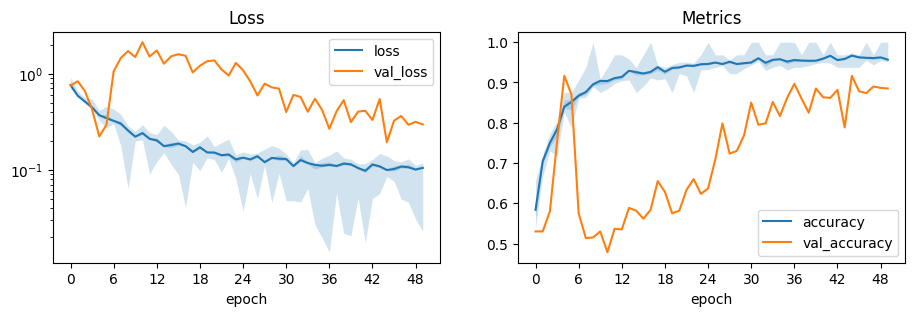

In [ ]:
tinstr.plot_train_history(history)

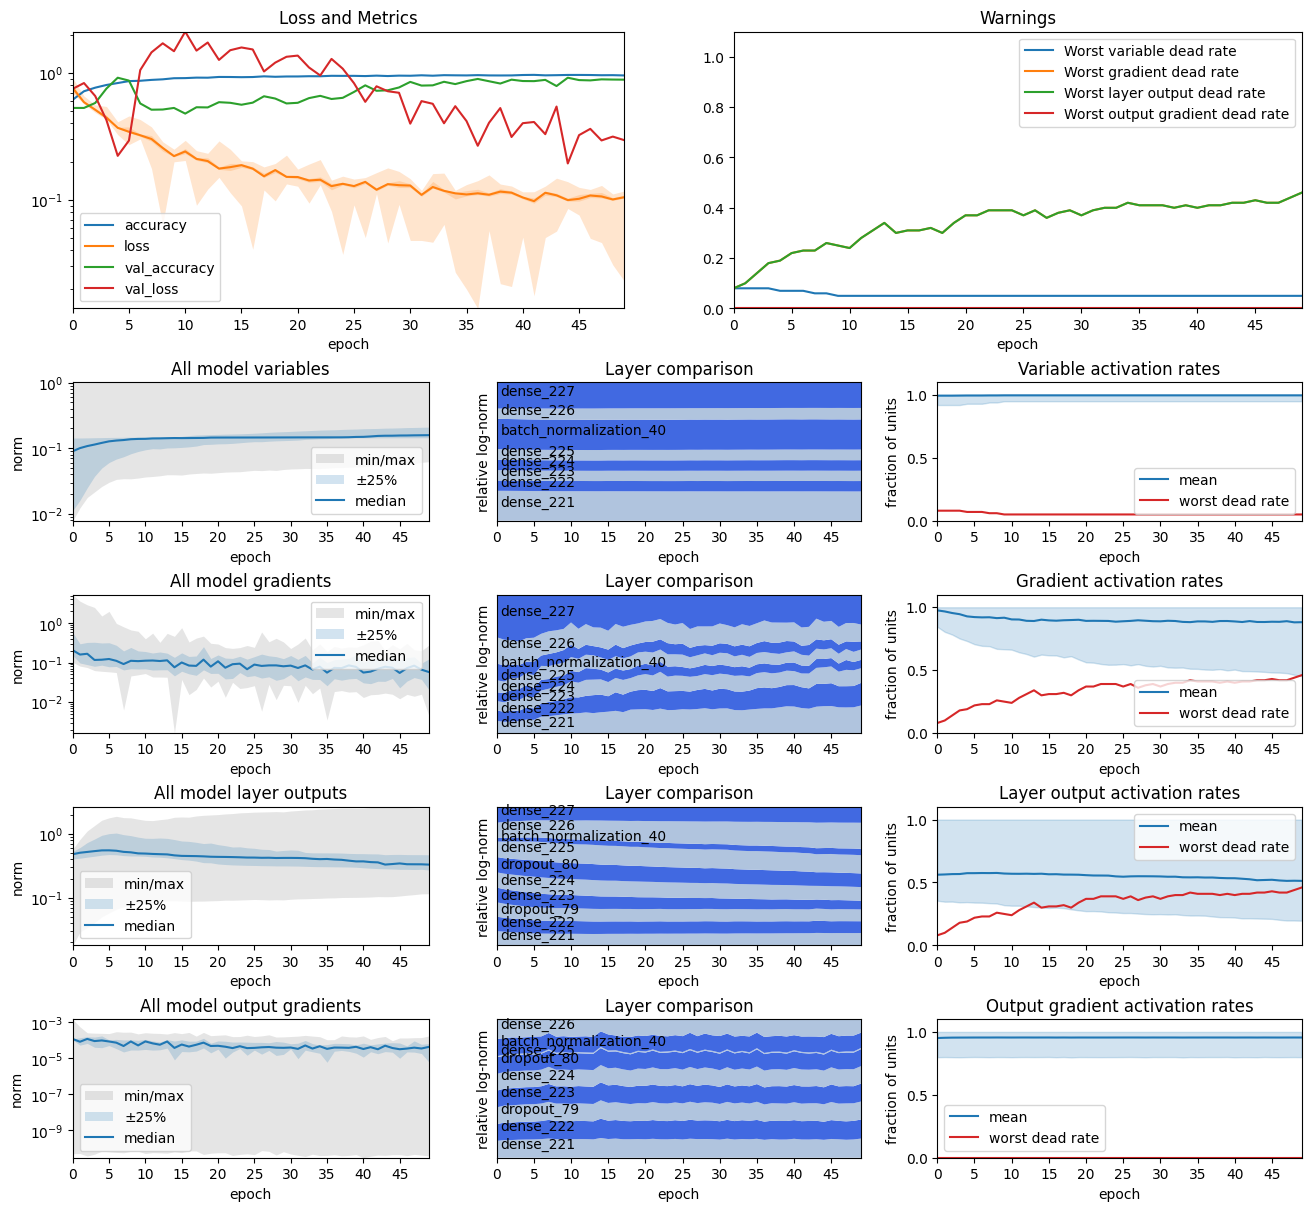

In [ ]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

## Basic Plotting of Weights and Biases

To get an idea of the effects of initialization, we can create a dummy model with different initialization schemes and their the weights and biases before training.

In [218]:
def short_path(variable_path):
  """converts from 'sequential_3/dense1/kernel' to 'sequential_3/dense1/kernel'"""
  return "/".join(variable_path.split("/")[-2:])

def percentiles_to_pdf(percentiles, quantiles=None):
  """Converts from percentile data an approximation of the probability density function (PDF)"""
  if quantiles is None:
    # assume each original quantile was evenly spaced from 0 to 100%
    quantiles = np.linspace(0, 1.0, len(percentiles))

  percentiles = np.array(percentiles)
  density = np.diff(quantiles) / np.diff(percentiles)
  print(f"{density=}")
  print(f"diffs={np.diff(percentiles)}")
  density = density / np.sum(density)
  mids = (percentiles[0:-1] + percentiles[1:]) / 2

  # add far-left and right-right zeros
  density = np.concatenate([[0], density, [0]])
  x = np.concatenate([[percentiles[0]], mids, [percentiles[-1]]])
  return x, density

def plot_variable_histograms(model):
  num_vars = len(model.trainable_variables)
  layer_indices = tinstr.layer_indices_by_trainable_variable(model)
  var_display_names = [f"layer {l_idx}:\n{short_path(v.path)}" for v, l_idx in zip(model.trainable_variables, layer_indices)]

  plot_cols = 4
  plot_rows = np.ceil(num_vars / plot_cols).astype(np.int32)
  plt.figure(figsize=(10, 2*plot_rows), layout='constrained')

  for v_idx, v in enumerate(model.trainable_variables):
    plt.subplot(plot_rows, plot_cols, v_idx+1)
    plt.title(var_display_names[v_idx])
    plt.hist(v.numpy().flatten(), bins=50)
    plt.xlabel("value")
    plt.ylabel("histogram count")
  plt.show()

def plot_latest_valuestats_pdf(callback):
  """Plots a probability-density-function (PDF) estimated from the latest value_stats of whichever callback is provided"""
  model = callback.model
  layer_indices = tinstr.layer_indices_by_variable(model)
  var_display_names = [f"layer {l_idx}:\n{short_path(v.path)}" for v, l_idx in zip(model.variables, layer_indices)]

  num_plots = len([v for v in callback.value_stats if v is not None])
  plot_cols = 4
  plot_rows = np.ceil(num_plots / plot_cols).astype(np.int32)
  plt.figure(figsize=(10, 2*plot_rows), layout='constrained')

  p_idx = 1
  for v_idx, stats_by_epoch in enumerate(callback.value_stats):
    if stats_by_epoch is not None:
      plt.subplot(plot_rows, plot_cols, p_idx)
      plt.title(var_display_names[v_idx])
      p_idx += 1

      # convert from percentile data to histogram bins and plot
      dist = stats_by_epoch.iloc[-1]
      quantiles = stats_by_epoch.columns

      print(f"{v_idx=}, stats_by_epoch={stats_by_epoch.shape}, dist={dist.to_numpy()}")

      x, y = percentiles_to_pdf(dist, quantiles)
      plt.plot(x,y)
      plt.fill_between(x, y, alpha=0.2)

      plt.xlabel("value")
      plt.ylabel("frequency")
      plt.yticks([])
  plt.show()

#plot_latest_valuestats_pdf(gradients)

In [229]:
def percentiles_to_pdf(percentiles, quantiles=None):
  """Converts from percentile data an approximation of the probability density function (PDF)"""
  if quantiles is None:
    # assume each original quantile was evenly spaced from 0 to 100%
    quantiles = np.linspace(0, 1.0, len(percentiles))

  percentiles = np.array(percentiles)
  widths = np.diff(percentiles)
  print(f"zeros: {np.sum(widths == 0.0)}, sum.widths={np.sum(widths)}, widths: {widths}")
  widths[widths == 0.0] = 1.0/len(percentiles) / np.sum(widths)
  print(f"zeros: {np.sum(widths == 0.0)}, sum.widths={np.sum(widths)}, widths: {widths}")

  density = np.diff(quantiles) / widths
  range = np.max(percentiles) - np.min(percentiles)
  print(f"{density=}")
  density = density / range
  print(f"{density=}")
  print(f"range={range}, diffs={np.diff(percentiles)}")
  density = density / np.sum(density)
  mids = (percentiles[0:-1] + percentiles[1:]) / 2

  # add far-left and right-right zeros
  density = np.concatenate([[0], density, [0]])
  x = np.concatenate([[percentiles[0]], mids, [percentiles[-1]]])
  return x, density

dist=[-1.1118063,  -0.03777332,  0.,          0.,          0.,          0.,  0.,          0.01340462,  1.1727257]
percentiles_to_pdf(dist)


zeros: 4, sum.widths=2.284532, widths: [1.07403298 0.03777332 0.         0.         0.         0.
 0.01340462 1.15932108]
zeros: 0, sum.widths=2.4790770728833933, widths: [1.07403298 0.03777332 0.04863627 0.04863627 0.04863627 0.04863627
 0.01340462 1.15932108]
density=array([0.11638376, 3.30921402, 2.5700985 , 2.5700985 , 2.5700985 ,
       2.5700985 , 9.32514312, 0.10782173])
density=array([0.05094425, 1.44853038, 1.125     , 1.125     , 1.125     ,
       1.125     , 4.08186146, 0.04719642])
range=2.284532, diffs=[1.07403298 0.03777332 0.         0.         0.         0.
 0.01340462 1.15932108]


(array([-1.1118063 , -0.57478981, -0.01888666,  0.        ,  0.        ,
         0.        ,  0.        ,  0.00670231,  0.59306516,  1.1727257 ]),
 array([0.        , 0.00502978, 0.14301483, 0.11107236, 0.11107236,
        0.11107236, 0.11107236, 0.40300621, 0.00465975, 0.        ]))

In [ ]:
model.variables[3].path

'sequential_39/dense_222/bias'

In [ ]:
gradients.value_stats[3].shape

(50, 9)

In [ ]:
gradients.value_stats[2].iloc[-1]

,49
0.0,-1.111806
12.5,-0.037773
25.0,0.000000
37.5,0.000000
50.0,0.000000
62.5,0.000000
75.0,0.000000
87.5,0.013405
100.0,1.172726


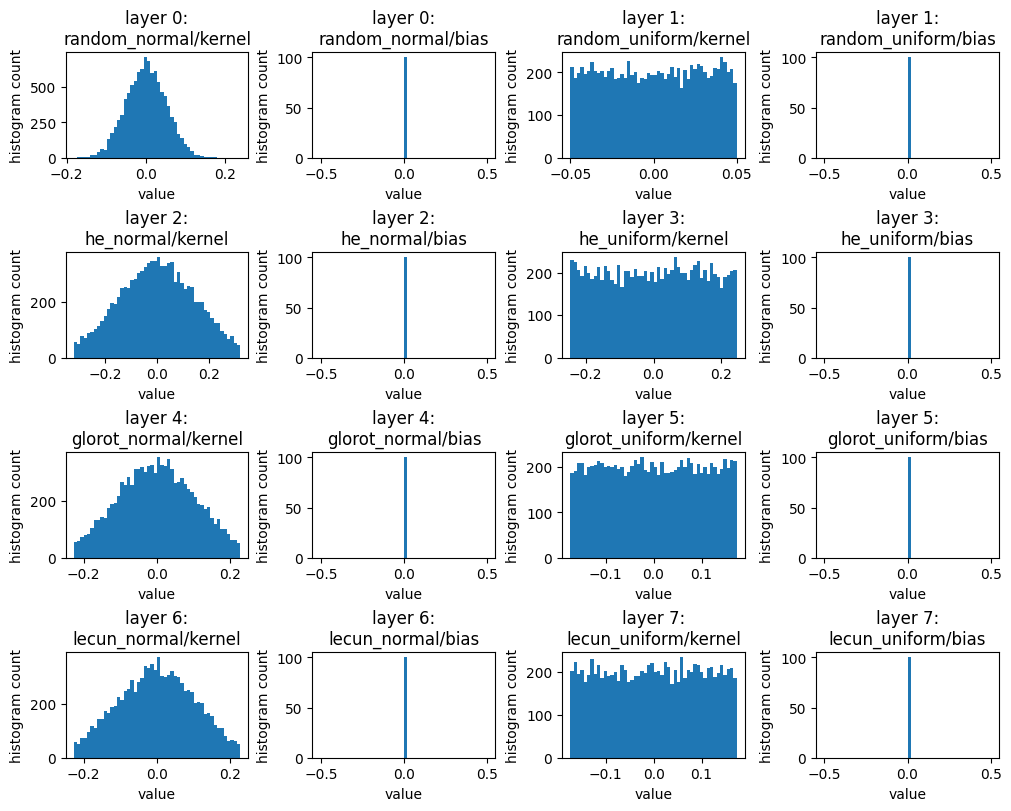

In [ ]:
def mixed_initialization_model():
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='random_normal', name='random_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='random_uniform', name='random_uniform'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal', name='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_uniform', name='he_uniform'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='glorot_normal', name='glorot_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='glorot_uniform', name='glorot_uniform'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='lecun_normal', name='lecun_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='lecun_uniform', name='lecun_uniform')
  ])
  return model

plot_variable_histograms(mixed_initialization_model())

Compare that to an initialized version of the model we're actually using:

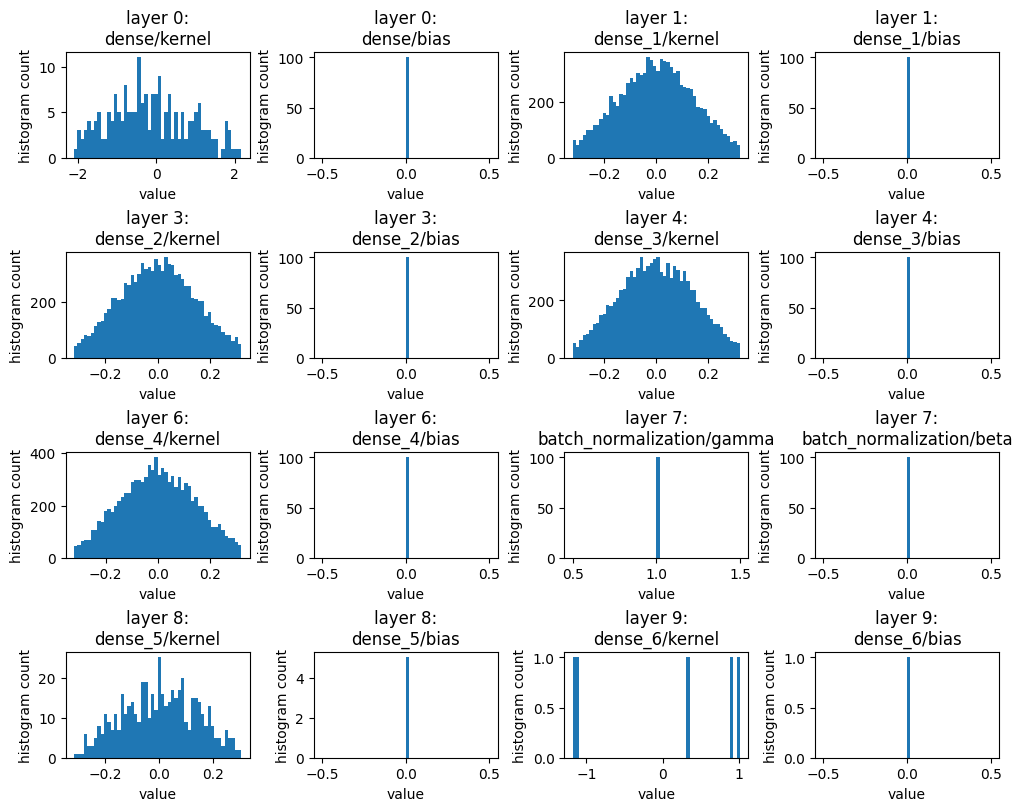

In [ ]:
plot_variable_histograms(binary_classification_model())

And then for our trained model...

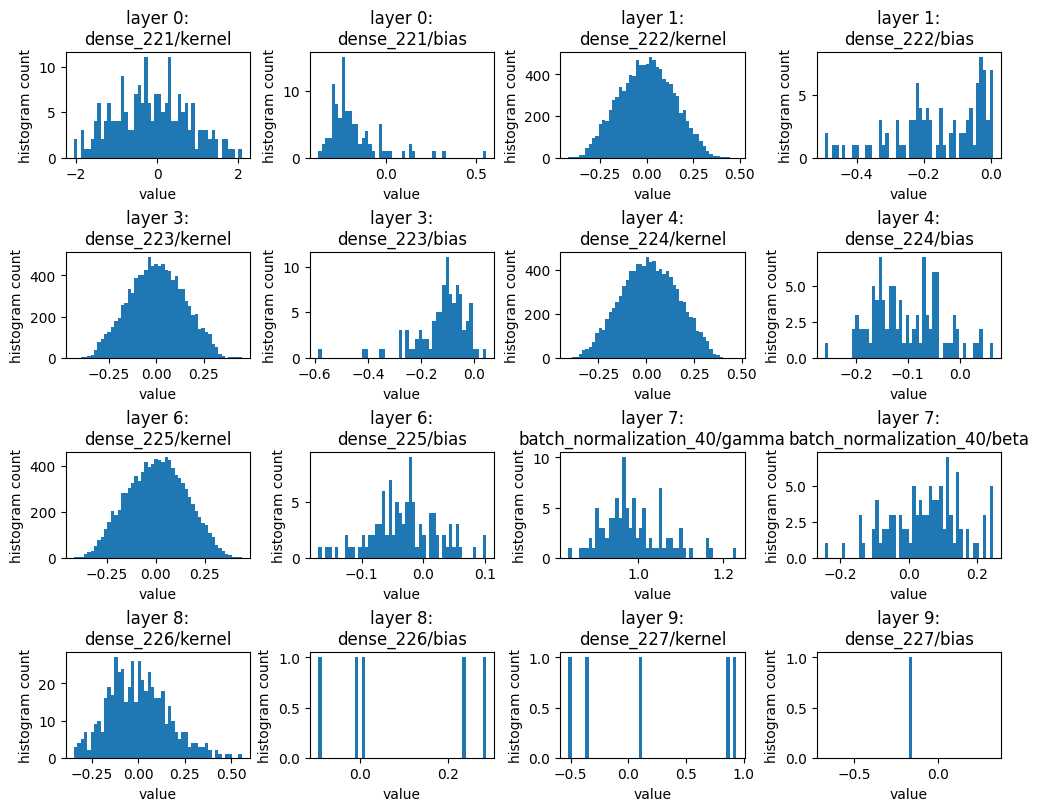

In [ ]:
plot_variable_histograms(model)

<ipython-input-199-603132c68334>:12: RuntimeWarning: divide by zero encountered in divide
  density = np.diff(quantiles) / np.diff(percentiles)
<ipython-input-199-603132c68334>:13: RuntimeWarning: invalid value encountered in divide
  density = density / np.sum(density)


IndexError: list index out of range

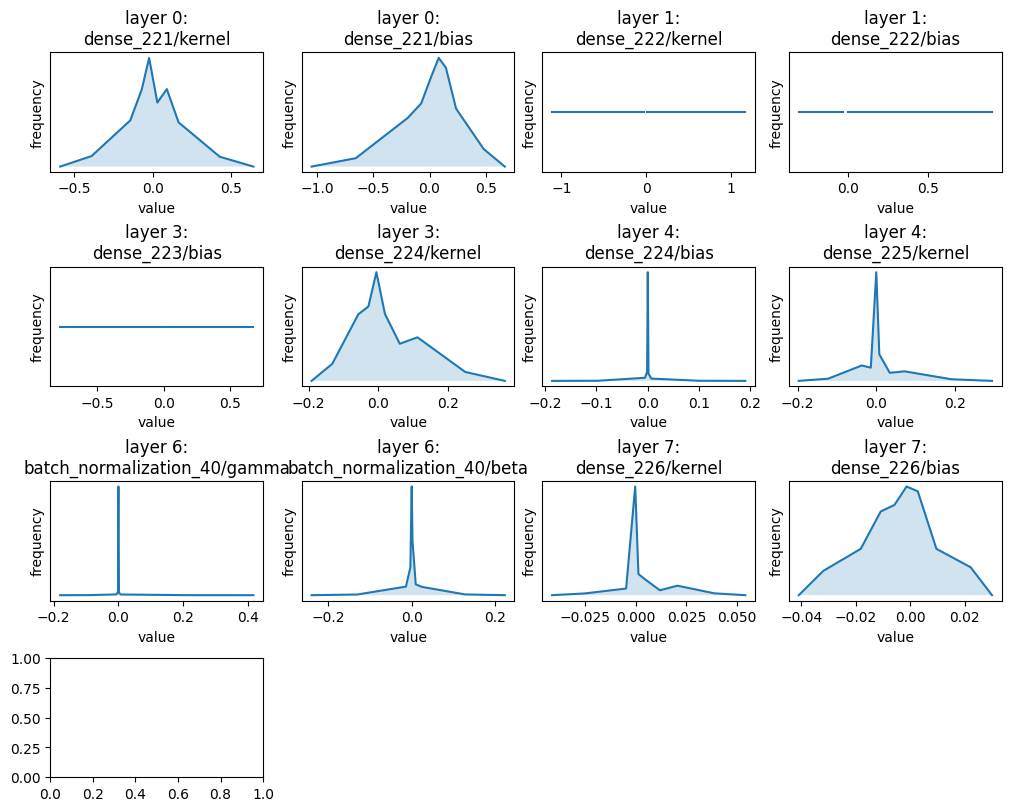

In [ ]:
plot_latest_valuestats_pdf(gradients)

## Plotting the weights and biases
There's several common ways of plotting weights:
* L2-norm aka euclidean norm (with/without size normalization)
* mean and stddev
* histograms

The following shows some of these options.


First, the L2-norm with size-normalization (ie: so that differently sized tensors still produce values on comparable scales), which is mathematically equivalent to calculating the RMS of the elements in each tensor:

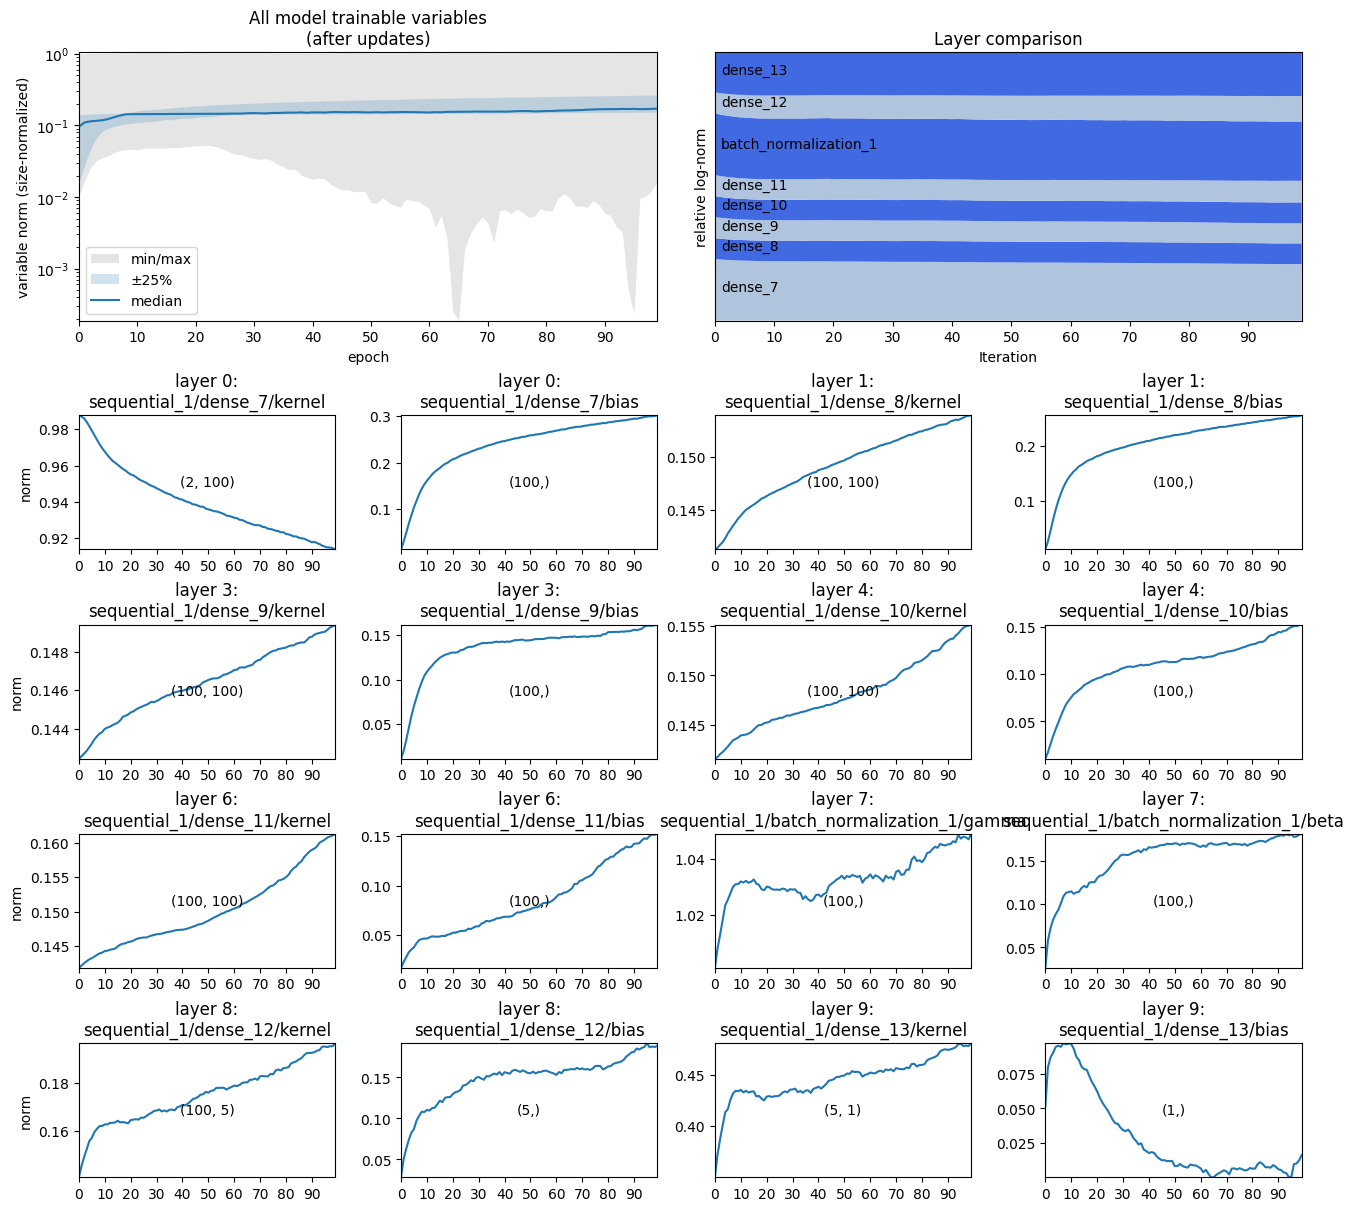

In [ ]:
tinstr.plot_value_history(variables, show='norms', yscale='linear')

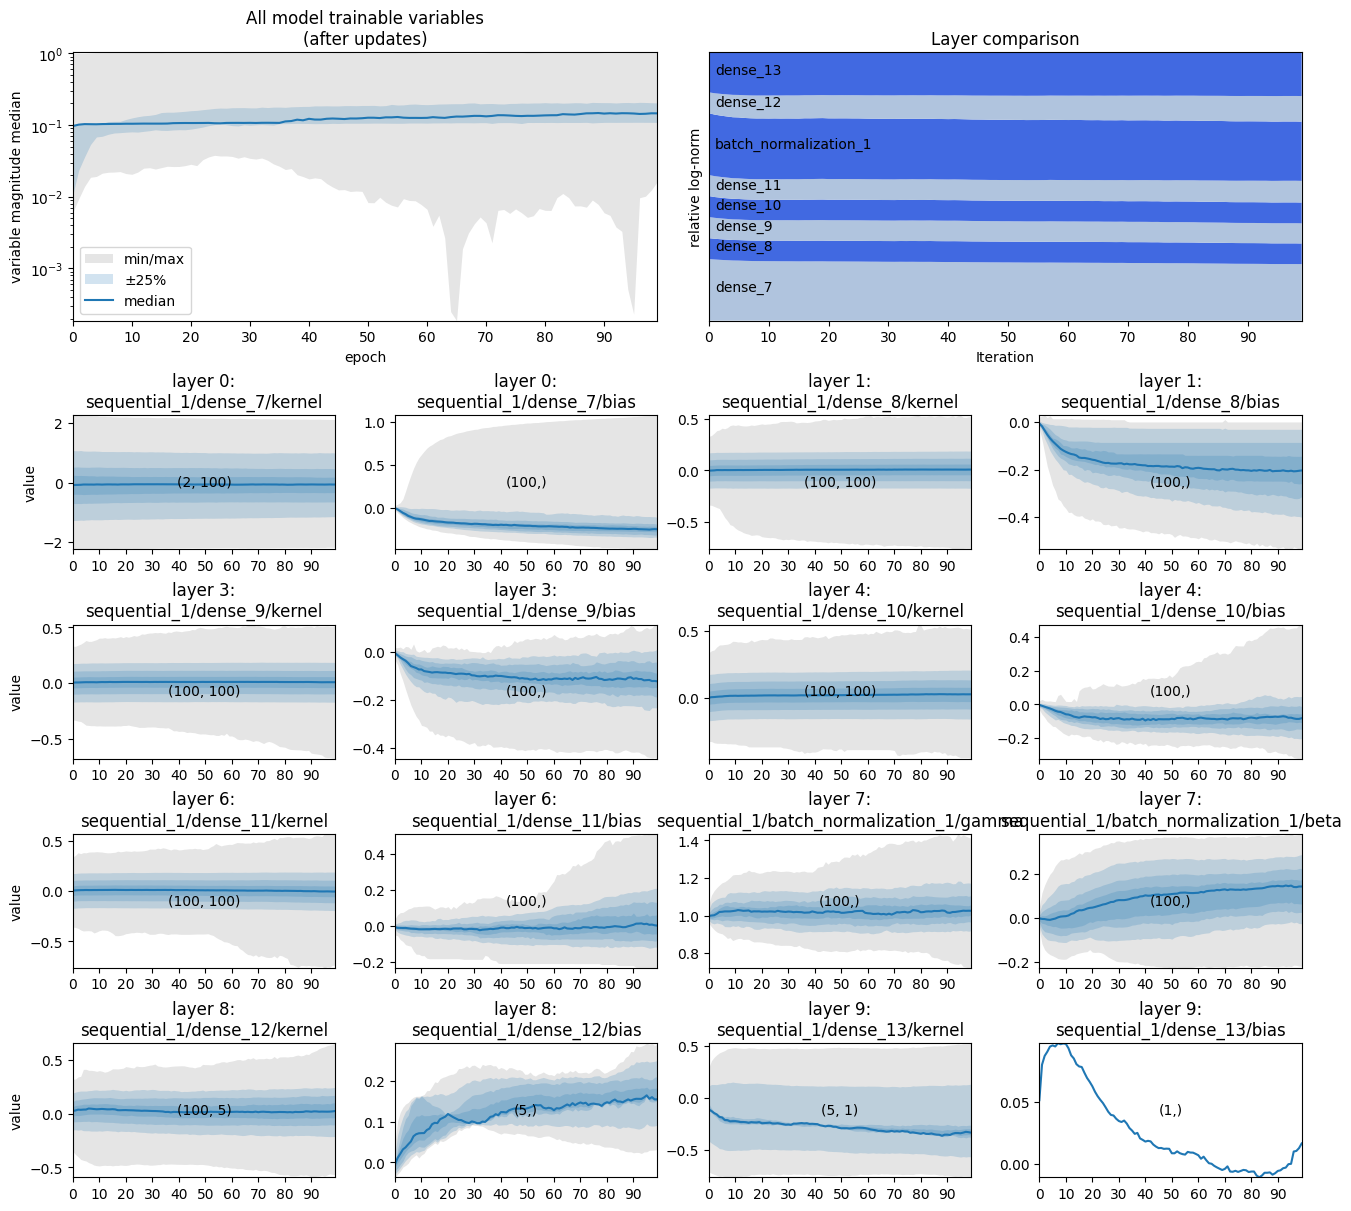

In [ ]:
tinstr.plot_value_history(variables, show='values')

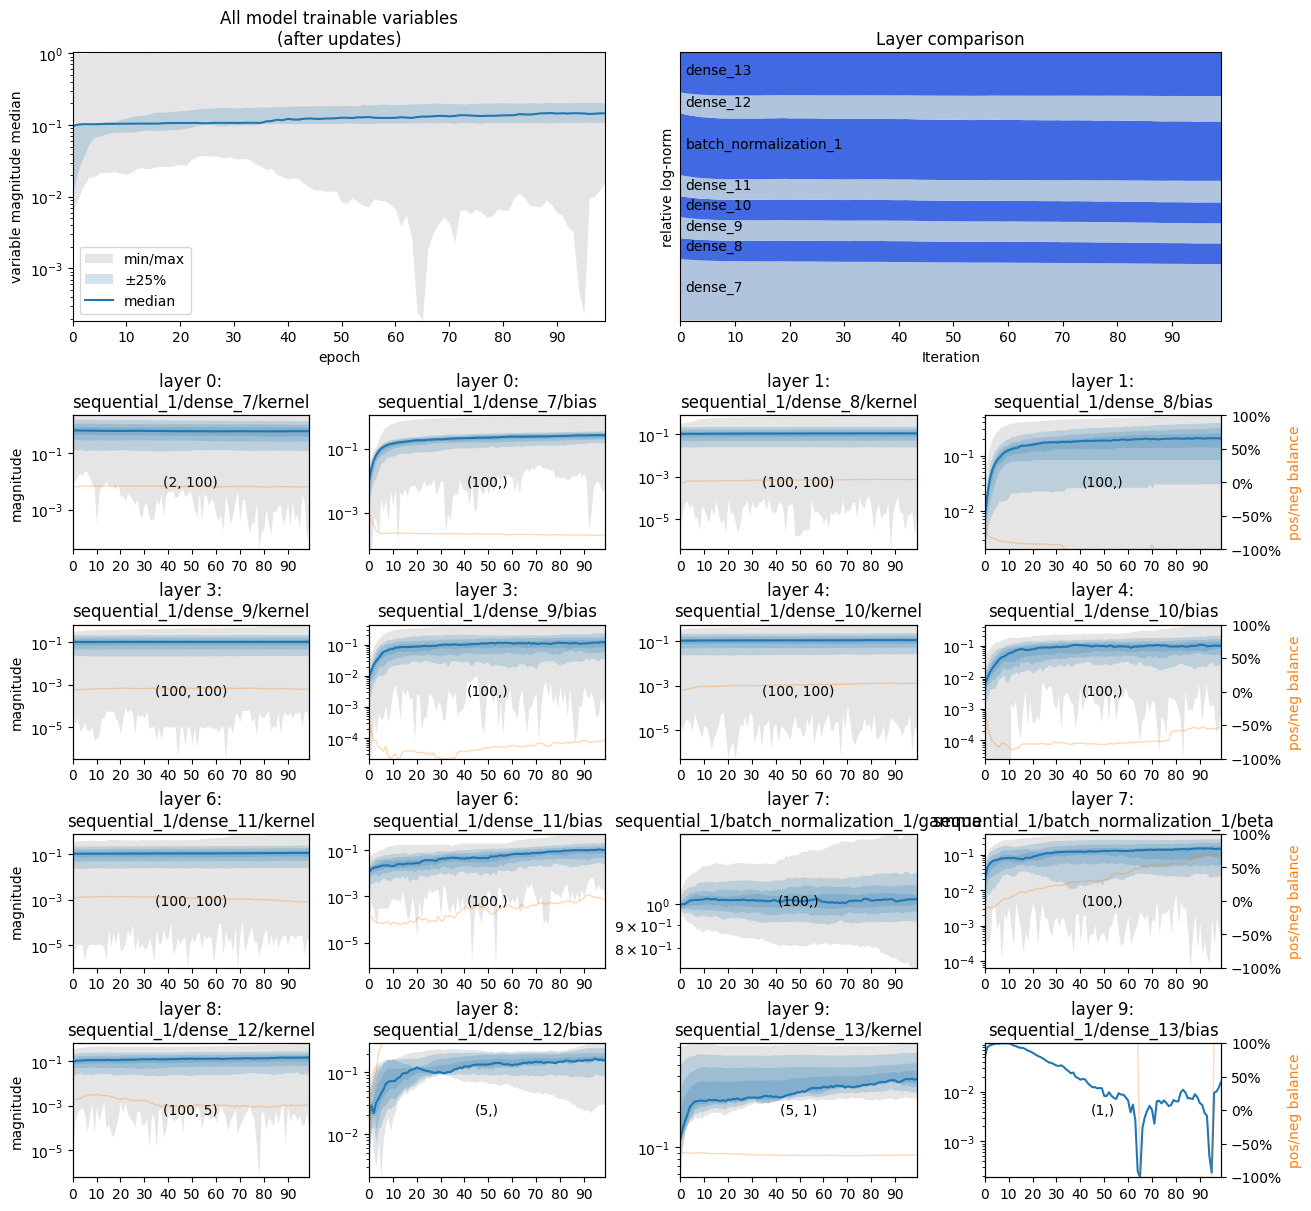

In [ ]:
tinstr.plot_value_history(variables, show='magnitudes')

## MNIST classification

In [ ]:
def mnist_dataset(train_size=5000, test_size=1000):
  """
  Uses a subset of the MNIST dataset, for faster training.
  We're interested in the visualization of results, not in getting the most accurate model.
  Note that the mnist data tends to be well shuffled already, so blindly taking the first N samples works well
  enough for our needs here.
  """
  (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
  #class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

  # pre-process into the correct data range and just use the first 5000 images
  train_images = train_images / 255.0
  test_images = test_images / 255.0

  # take first N samples
  if train_size is not None:
    train_images = train_images[0:train_size]
    train_labels = train_labels[0:train_size]
  if test_size is not None:
    test_images = test_images[0:test_size]
    test_labels = test_labels[0:test_size]

  print(f"train: inputs={train_images.shape}, labels={train_labels.shape}")
  print(f"test:  inputs={test_images.shape}, labels={test_labels.shape}")

  train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels)).batch(32)
  test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels)).batch(32)
  return train_dataset, test_dataset

In [ ]:
def mnist_classification_model():
  inp = tf.keras.layers.Input((28, 28), name="input")
  x = tf.keras.layers.Reshape((28,28,1), name="reshape")(inp)

  x = tf.keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv1a")(x)
  x = tf.keras.layers.Conv2D(filters=16, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv1b")(x)
  x = layers.BatchNormalization(name="batchNorm1")(x)
  x = tf.keras.layers.MaxPool2D(pool_size=2, padding='valid', name="pool1")(x)
  x = layers.Dropout(0.2, name="dropout1")(x)

  x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv2a")(x)
  x = tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer='he_normal', name="conv2b")(x)
  x = layers.BatchNormalization(name="batchNorm2")(x)
  x = tf.keras.layers.MaxPool2D(pool_size=2, padding='valid', name="pool2")(x)
  x = layers.Dropout(0.2, name="dropout2")(x)

  x = tf.keras.layers.Flatten(name="flatten")(x)
  x = tf.keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal', name="dense1")(x)
  x = tf.keras.layers.Dense(units=128, activation='relu', kernel_initializer='he_normal', name="dense2")(x)
  x = tf.keras.layers.Dense(units=10, kernel_initializer='glorot_normal', name="logits")(x)
  return tf.keras.Model(inputs=inp, outputs=x)

mnist_classification_model().summary()

Model: "functional_71"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1a (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 24, 24, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 10, 10, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,834 (389.98 KB)

 Trainable params: 99,834 (389.98 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = mnist_classification_model()
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
train_dataset, val_dataset = mnist_dataset()
history = tinstr.fit(model, train_dataset, validation_data=val_dataset, epochs=20, verbose=0,
                     callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

train: inputs=(5000, 28, 28), labels=(5000,)
test:  inputs=(1000, 28, 28), labels=(1000,)
Epoch     2 - 6.95s/epoch: accuracy: 0.8052  loss: 0.5284  val_accuracy: 0.8040  val_loss: 0.5459  
Epoch     4 - 2.55s/epoch: accuracy: 0.8584  loss: 0.3842  val_accuracy: 0.8370  val_loss: 0.5166  
Epoch     6 - 2.24s/epoch: accuracy: 0.8936  loss: 0.2941  val_accuracy: 0.8480  val_loss: 0.4973  
Epoch     8 - 2.33s/epoch: accuracy: 0.9124  loss: 0.2500  val_accuracy: 0.8410  val_loss: 0.4929  
Epoch    10 - 2.47s/epoch: accuracy: 0.9348  loss: 0.1828  val_accuracy: 0.8650  val_loss: 0.5511  
Epoch    12 - 2.22s/epoch: accuracy: 0.9468  loss: 0.1497  val_accuracy: 0.8480  val_loss: 0.6099  
Epoch    14 - 2.51s/epoch: accuracy: 0.9594  loss: 0.1194  val_accuracy: 0.8590  val_loss: 0.5905  
Epoch    16 - 2.24s/epoch: accuracy: 0.9596  loss: 0.1145  val_accuracy: 0.8480  val_loss: 0.6448  
Epoch    18 - 2.22s/epoch: accuracy: 0.9702  loss: 0.0870  val_accuracy: 0.8490  val_loss: 0.6432  
Epoch    2

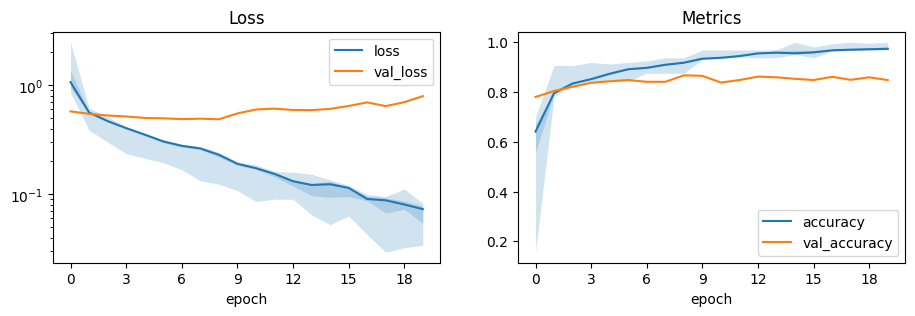

In [ ]:
tinstr.plot_train_history(history)

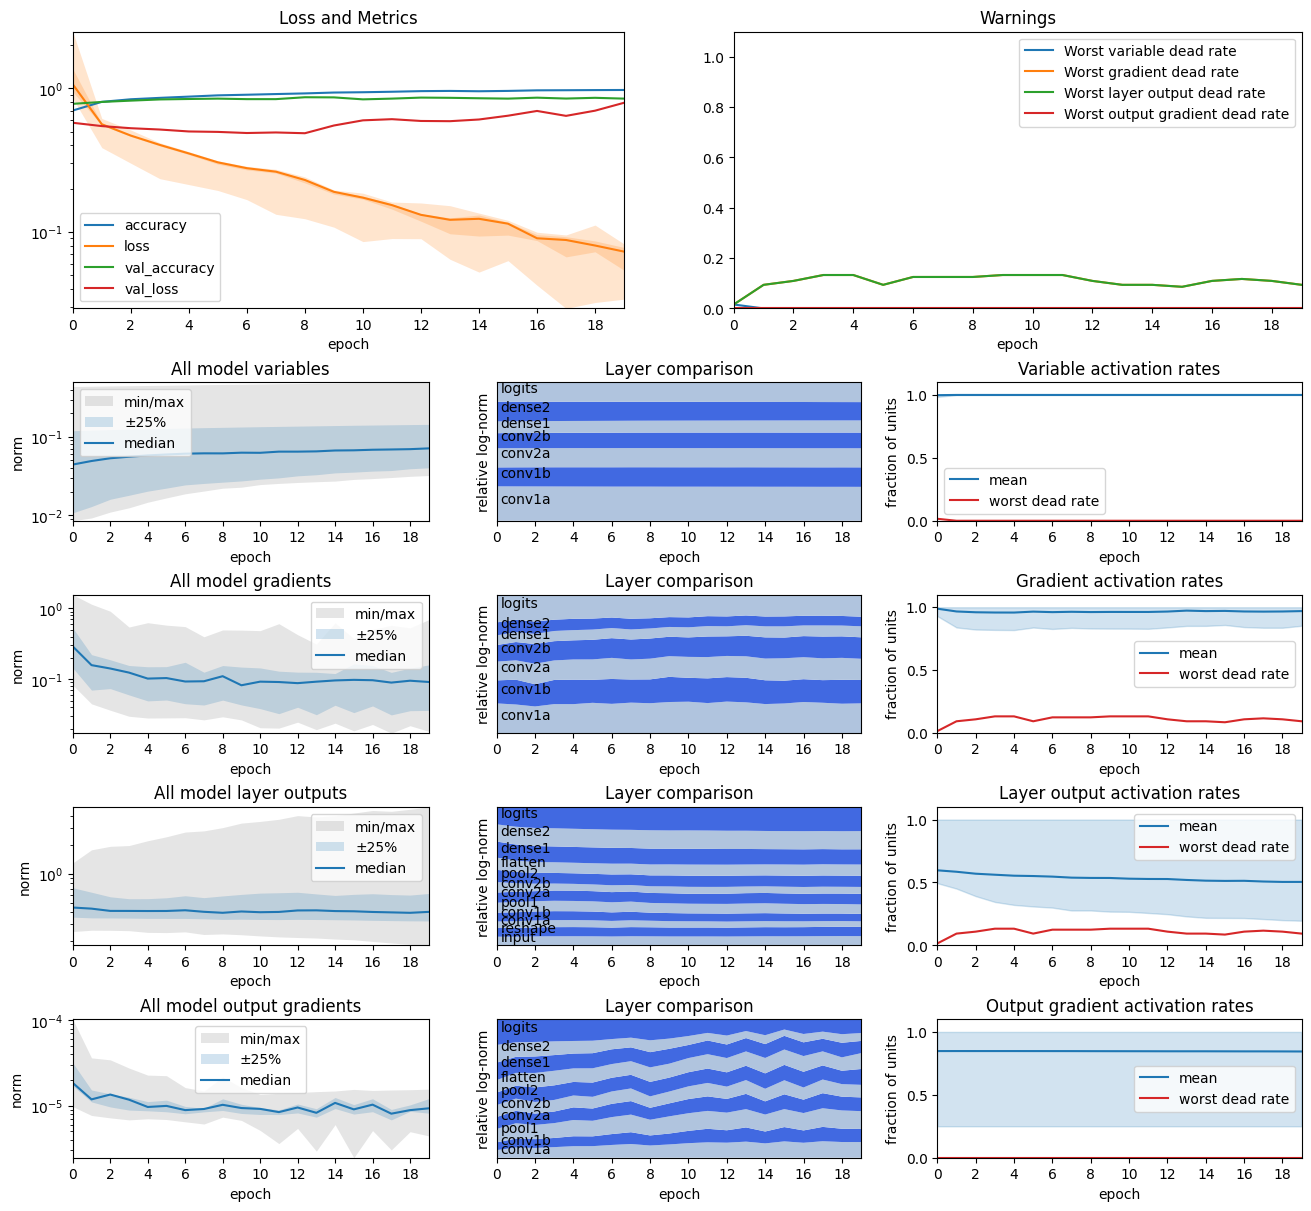

In [ ]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

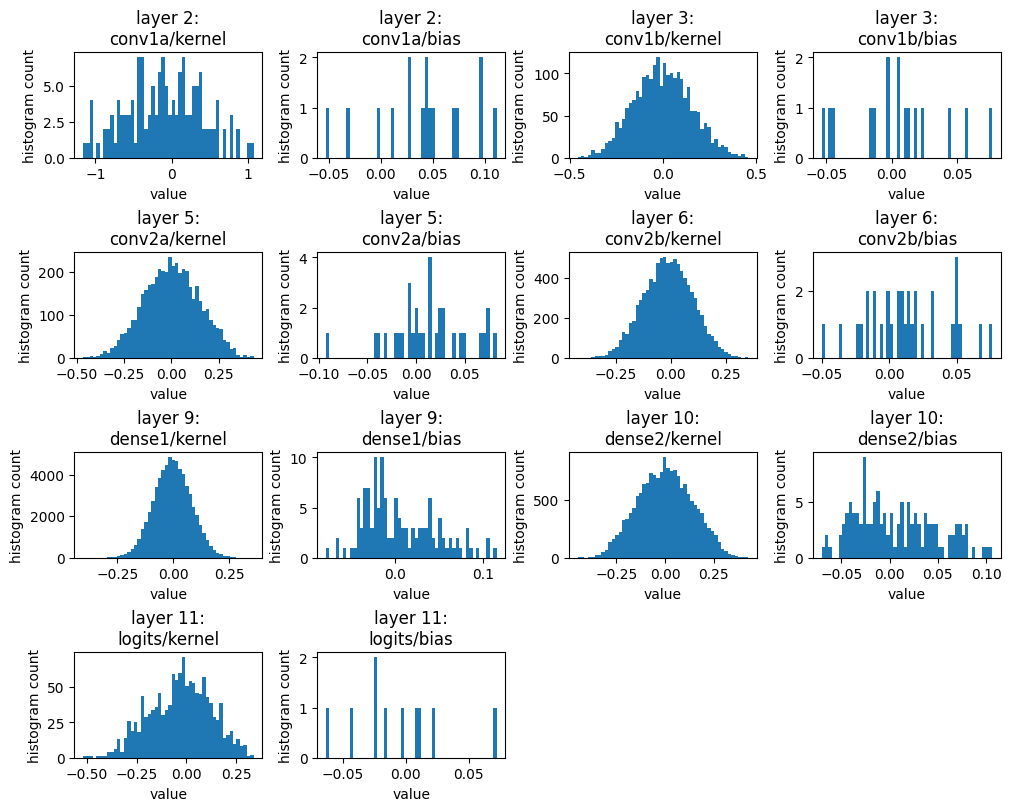

In [ ]:
plot_variable_histograms(model)

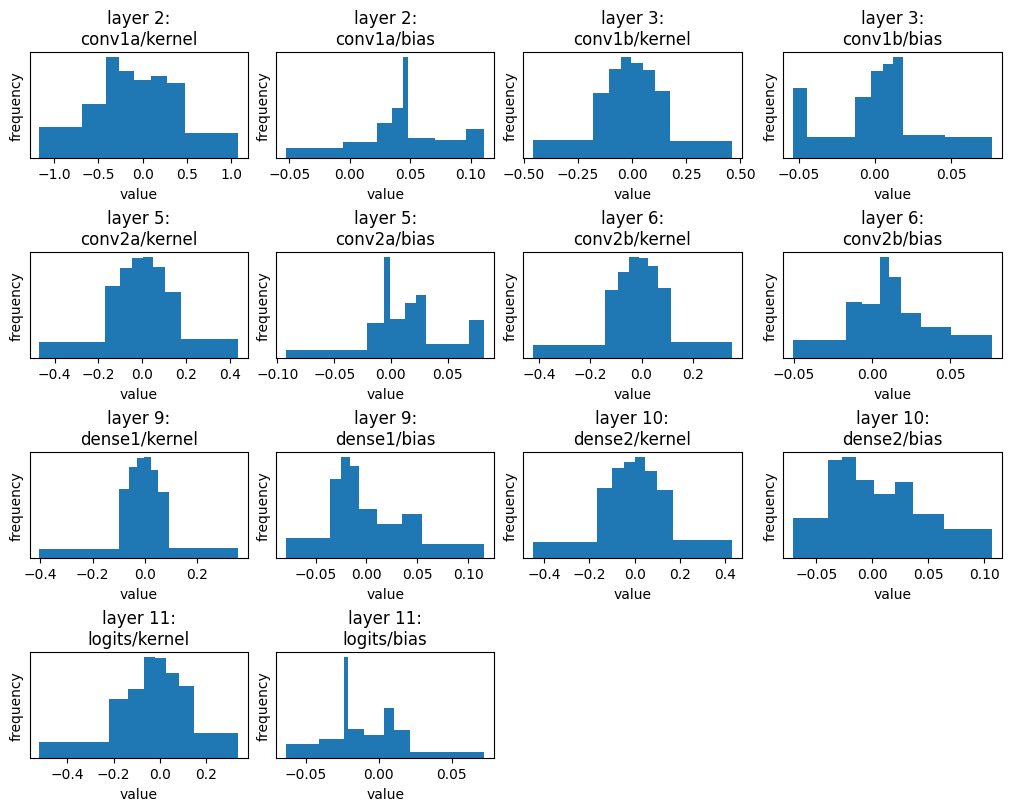

In [ ]:
plot_latest_valuestats_histograms(variables)

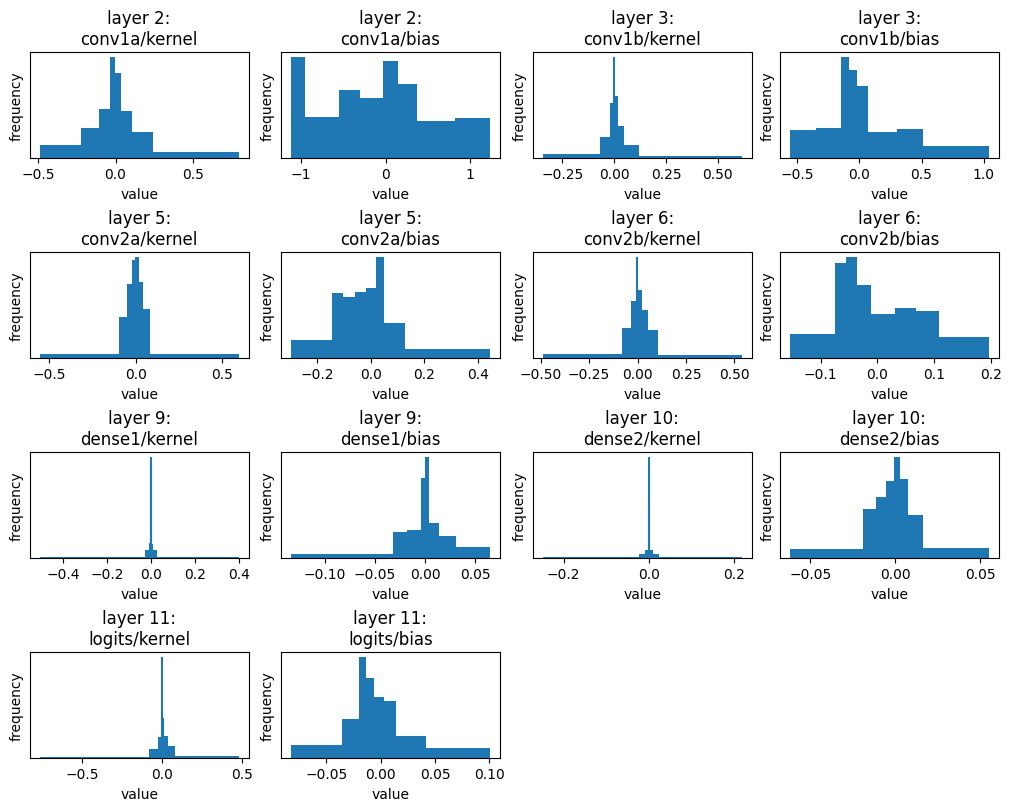

In [ ]:
plot_latest_valuestats_histograms(gradients)

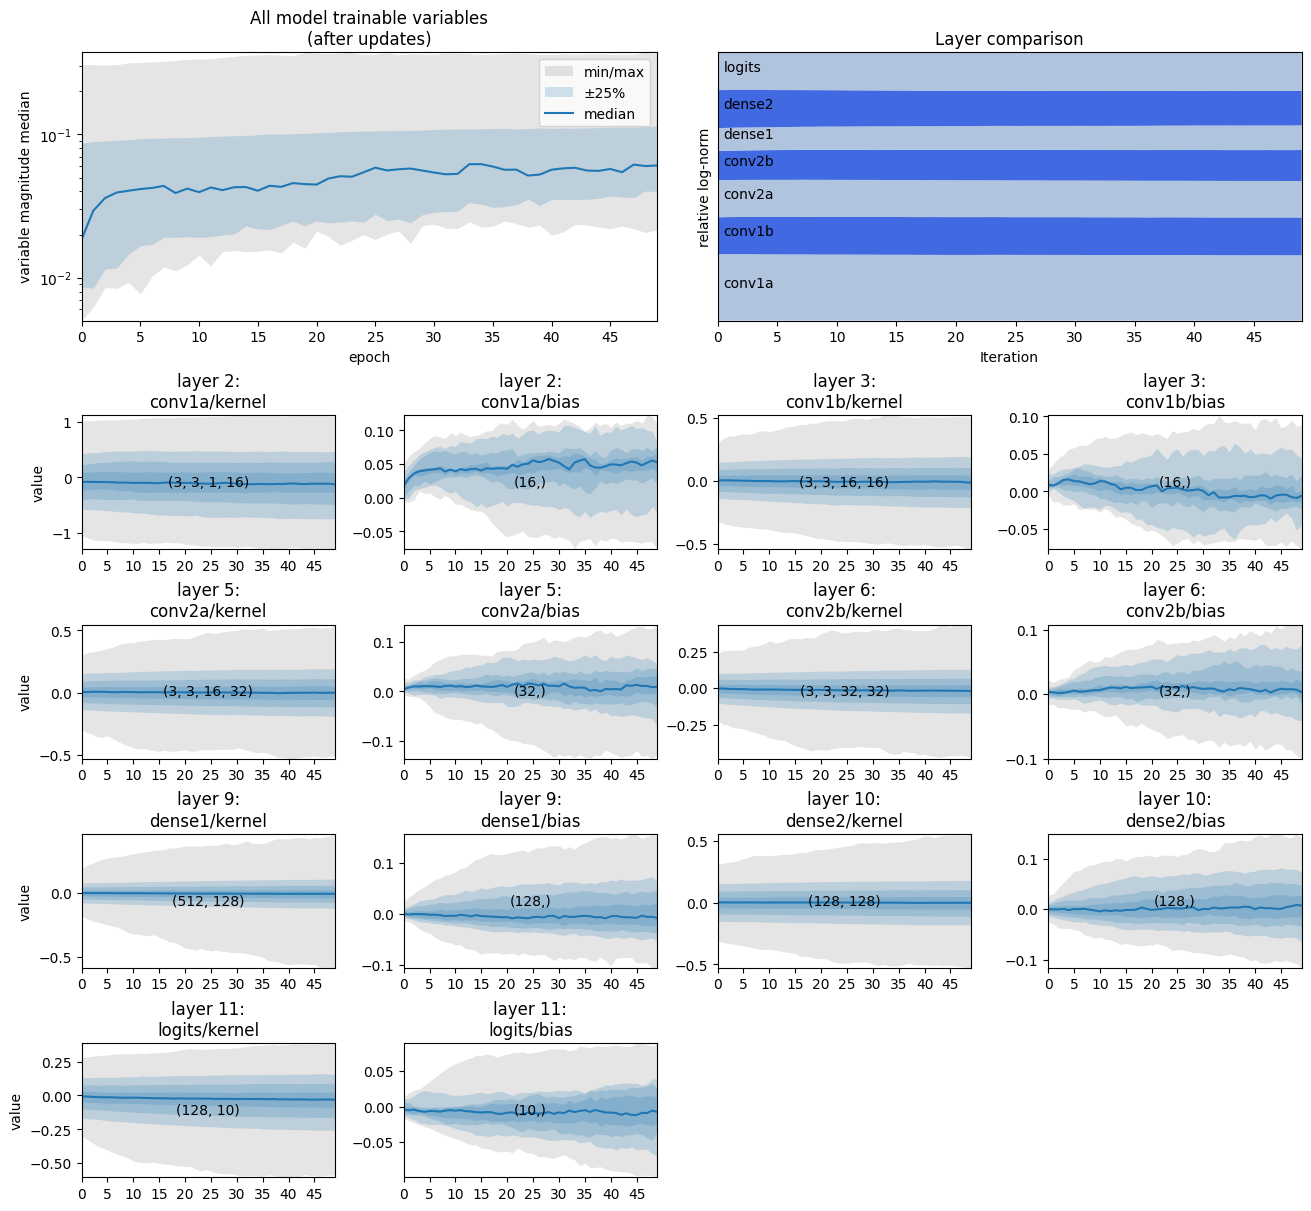

In [ ]:
tinstr.plot_value_history(variables, show='values')

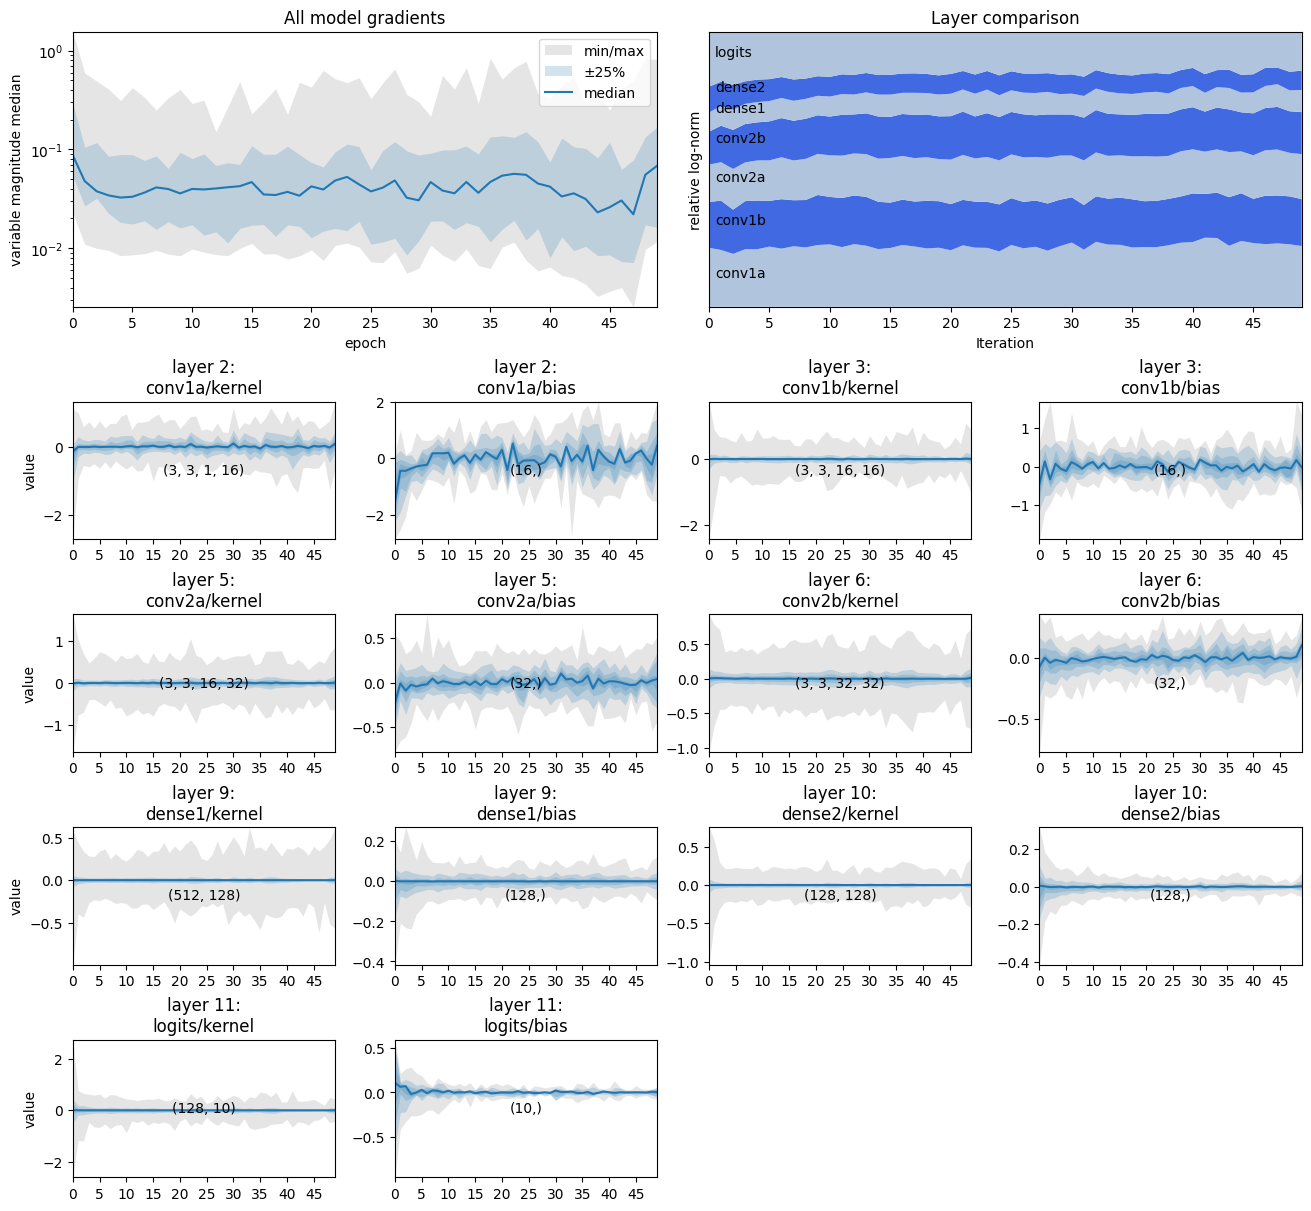

In [ ]:
tinstr.plot_value_history(gradients, show='values')

## Appendix: Experimenting with different MNIST models

In [ ]:
def simple_mnist_model():
  model = tf.keras.Sequential([
      layers.Input(shape=(28, 28, 1)),
      layers.Flatten(),
      layers.Dense(256, activation="relu"),
      layers.Dropout(0.2),
      layers.Dense(128, activation="relu"),
      layers.Dropout(0.2),
      layers.Dense(10, activation="softmax")
  ])
  return model
#simple_mnist_model().summary()

def mnist_medium_model():
  model = tf.keras.Sequential([
      layers.Conv2D(32, 3, activation='relu', input_shape=(28, 28, 1)),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(128, 3, activation='relu'),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dropout(0.3),
      layers.Dense(10, activation='softmax')
  ])
  return model
#mnist_medium_model().summary()

In [ ]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = simple_mnist_model()
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy', tf.keras.metrics.SparseCategoricalAccuracy()])
dataset = mnist_dataset()
history = tinstr.fit(model, dataset, epochs=10, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

train_images shape: (5000, 28, 28)
train_labels shape: (5000,)
Epoch     1 - 5.93s/epoch: accuracy: 0.6696  loss: 0.9211  sparse_categorical_accuracy: 0.6696  


Epoch     2 - 5.69s/epoch: accuracy: 0.7872  loss: 0.5915  sparse_categorical_accuracy: 0.7872  
Epoch     3 - 2.38s/epoch: accuracy: 0.8176  loss: 0.5079  sparse_categorical_accuracy: 0.8176  
Epoch     4 - 3.38s/epoch: accuracy: 0.8328  loss: 0.4626  sparse_categorical_accuracy: 0.8328  
Epoch     5 - 2.40s/epoch: accuracy: 0.8504  loss: 0.4192  sparse_categorical_accuracy: 0.8504  
Epoch     6 - 2.42s/epoch: accuracy: 0.8560  loss: 0.3908  sparse_categorical_accuracy: 0.8560  
Epoch     7 - 2.37s/epoch: accuracy: 0.8648  loss: 0.3700  sparse_categorical_accuracy: 0.8648  
Epoch     8 - 2.56s/epoch: accuracy: 0.8698  loss: 0.3546  sparse_categorical_accuracy: 0.8698  
Epoch     9 - 3.47s/epoch: accuracy: 0.8774  loss: 0.3352  sparse_categorical_accuracy: 0.8774  
Epoch    10 - 2.39s/epoch: accuracy: 0.8780  loss: 0.3234  sparse_categorical_accuracy: 0.8780  
Total training time: 33.1 sec


In [ ]:
tf.keras.utils.set_random_seed(1)

# Run a full training sequence and collect default information for each of the four main callbacks.
# We'll also use the extended `HistoryStats` callback for loss and metric history.
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = mnist_medium_model()
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=['accuracy', tf.keras.metrics.SparseCategoricalAccuracy()])
dataset = mnist_dataset()
history = tinstr.fit(model, dataset, epochs=10, verbose=0, callbacks=[tinstr.LessVerboseProgressLogger(), variables, gradients, outputs, output_gradients, tinstr.HistoryStats()])

# PS: any tf.function retracing warnings can be safely ignored.

train_images shape: (5000, 28, 28)
train_labels shape: (5000,)
Epoch     1 - 12.37s/epoch: accuracy: 0.6108  loss: 1.0728  sparse_categorical_accuracy: 0.6108  
Epoch     2 - 14.31s/epoch: accuracy: 0.7710  loss: 0.6300  sparse_categorical_accuracy: 0.7710  
Epoch     3 - 10.26s/epoch: accuracy: 0.7994  loss: 0.5393  sparse_categorical_accuracy: 0.7994  
Epoch     4 - 7.90s/epoch: accuracy: 0.8246  loss: 0.4817  sparse_categorical_accuracy: 0.8246  
Epoch     5 - 10.56s/epoch: accuracy: 0.8412  loss: 0.4277  sparse_categorical_accuracy: 0.8412  
Epoch     6 - 9.04s/epoch: accuracy: 0.8582  loss: 0.3868  sparse_categorical_accuracy: 0.8582  
Epoch     7 - 8.27s/epoch: accuracy: 0.8748  loss: 0.3507  sparse_categorical_accuracy: 0.8748  
Epoch     8 - 9.91s/epoch: accuracy: 0.8798  loss: 0.3302  sparse_categorical_accuracy: 0.8798  
Epoch     9 - 9.06s/epoch: accuracy: 0.8918  loss: 0.3106  sparse_categorical_accuracy: 0.8918  
Epoch    10 - 10.68s/epoch: accuracy: 0.8980  loss: 0.2857  